In [1]:
import pandas as pd
import numpy as np
from catboost import CatBoostClassifier, Pool
from sklearn.metrics import (classification_report,
                             confusion_matrix,
                             roc_auc_score)
import matplotlib.pyplot as plt
import seaborn as sns

print("All imports successfull!")

All imports successfull!


In [2]:
df = pd.read_csv('../data/american_bankruptcy_dataset.csv')

print("Data loaded!", df.shape)

Data loaded! (78682, 23)


In [3]:
df['target'] = (df['status_label'] == 'failed').astype(int)

print(df['target'].value_counts())

target
0    73462
1     5220
Name: count, dtype: int64


In [4]:
train_df = df[df['fyear'] <= 2011]
val_df   = df[(df['fyear'] >= 2012) & (df['fyear'] <= 2014)]
test_df  = df[df['fyear'] >= 2015]

print("Train size:", len(train_df))
print("Validation size:", len(val_df))
print("Test size:", len(test_df))

Train size: 55927
Validation size: 10473
Test size: 12282


In [5]:
FEATURES = ['X1','X2','X3','X4','X5','X6','X7','X8',
            'X9','X10','X11','X12','X13','X14','X15',
            'X16','X17','X18','Division']

X_train = train_df[FEATURES]
y_train = train_df['target']

X_val = val_df[FEATURES]
y_val = val_df['target']

X_test = test_df[FEATURES]
y_test = test_df['target']

print("X_train shape:", X_train.shape)
print("X_val shape:", X_val.shape)
print("X_test shape:", X_test.shape)

X_train shape: (55927, 19)
X_val shape: (10473, 19)
X_test shape: (12282, 19)


In [6]:
alive = (y_train == 0).sum()
failed = (y_train == 1).sum()
scale_weight = 6

print(f"Alive: {alive}")
print(f"Failed: {failed}")
print(f"Scale weight (fixed): {scale_weight}")


Alive: 51485
Failed: 4442
Scale weight (fixed): 6


In [7]:
cat_feature_indices = [FEATURES.index('Division')]

train_pool = Pool(X_train, y_train, cat_features=cat_feature_indices)
val_pool   = Pool(X_val,   y_val,   cat_features=cat_feature_indices)
test_pool  = Pool(X_test,  y_test,  cat_features=cat_feature_indices)

print("Pools created successfully!")

Pools created successfully!


In [8]:
model = CatBoostClassifier(
    iterations=500,
    learning_rate=0.05,
    depth=6,
    loss_function='Logloss',
    eval_metric='AUC',
    random_seed=42,
    early_stopping_rounds=50,
    scale_pos_weight=scale_weight,
    verbose=50
)

print("Model defined successfully!")

Model defined successfully!


In [9]:
model.fit(
    train_pool,
    eval_set=val_pool,
    plot=False
)

print("Training complete!")

0:	test: 0.7417727	best: 0.7417727 (0)	total: 311ms	remaining: 2m 35s
50:	test: 0.8136113	best: 0.8138046 (49)	total: 4.87s	remaining: 42.9s
100:	test: 0.8198976	best: 0.8200629 (97)	total: 9.15s	remaining: 36.1s
150:	test: 0.8220795	best: 0.8221557 (126)	total: 13.4s	remaining: 30.9s
200:	test: 0.8224213	best: 0.8228047 (199)	total: 17.6s	remaining: 26.1s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.8228046737
bestIteration = 199

Shrink model to first 200 iterations.
Training complete!


In [10]:
import os
os.makedirs('../model', exist_ok=True)

model.save_model('../model/catboost_bankruptcy.cbm')
print("Model saved successfully!")

Model saved successfully!


In [11]:
y_val_pred = model.predict(val_pool)
y_val_proba = model.predict_proba(val_pool)[:, 1]

val_auc = roc_auc_score(y_val, y_val_proba)
print(f"Validation AUC: {val_auc:.4f}")
print()
print(classification_report(y_val, y_val_pred,
      target_names=['Alive', 'Failed']))

Validation AUC: 0.8228

              precision    recall  f1-score   support

       Alive       0.97      0.93      0.95      9982
      Failed       0.23      0.45      0.31       491

    accuracy                           0.91     10473
   macro avg       0.60      0.69      0.63     10473
weighted avg       0.94      0.91      0.92     10473



In [12]:
y_test_pred = model.predict(test_pool)
y_test_proba = model.predict_proba(test_pool)[:, 1]

test_auc = roc_auc_score(y_test, y_test_proba)
print(f"Test AUC: {test_auc:.4f}")
print()
print(classification_report(y_test, y_test_pred,
      target_names=['Alive', 'Failed']))

Test AUC: 0.8241

              precision    recall  f1-score   support

       Alive       0.99      0.91      0.95     11995
      Failed       0.12      0.51      0.19       287

    accuracy                           0.90     12282
   macro avg       0.55      0.71      0.57     12282
weighted avg       0.97      0.90      0.93     12282



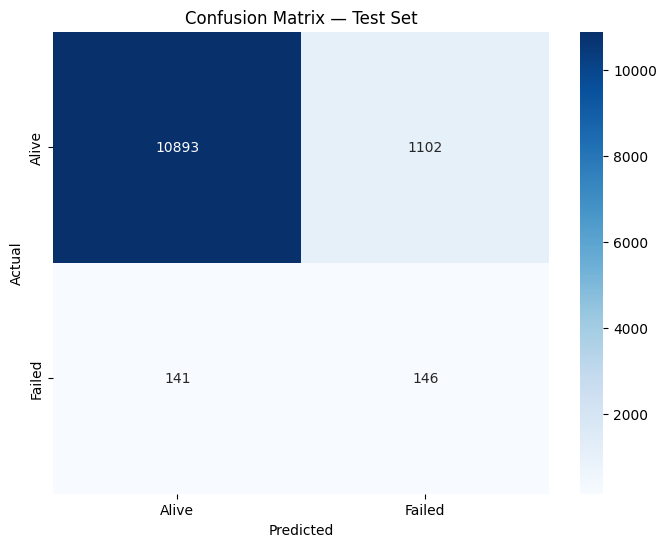

In [13]:
cm = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Alive', 'Failed'],
            yticklabels=['Alive', 'Failed'])
plt.title('Confusion Matrix — Test Set')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

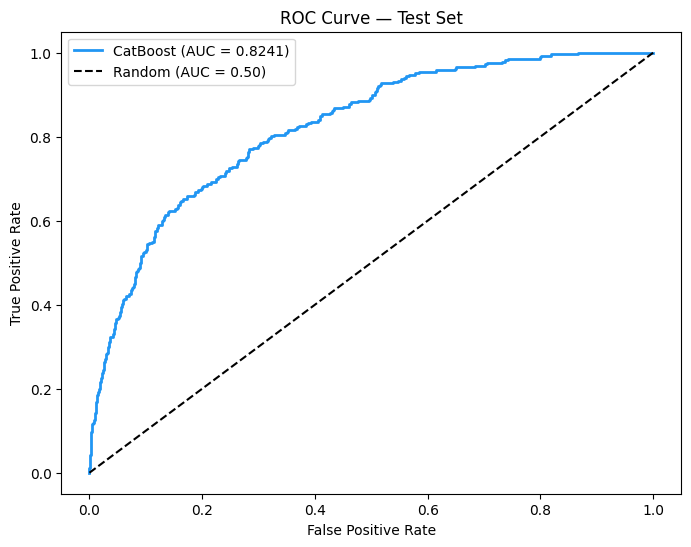

In [14]:
from sklearn.metrics import roc_curve

fpr, tpr, _ = roc_curve(y_test, y_test_proba)

plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, color='#2196F3', lw=2, 
         label=f'CatBoost (AUC = {test_auc:.4f})')
plt.plot([0,1],[0,1], 'k--', label='Random (AUC = 0.50)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — Test Set')
plt.legend()
plt.show()

C:\Users\jilan\AppData\Local\Temp\ipykernel_11476\3796585095.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature',


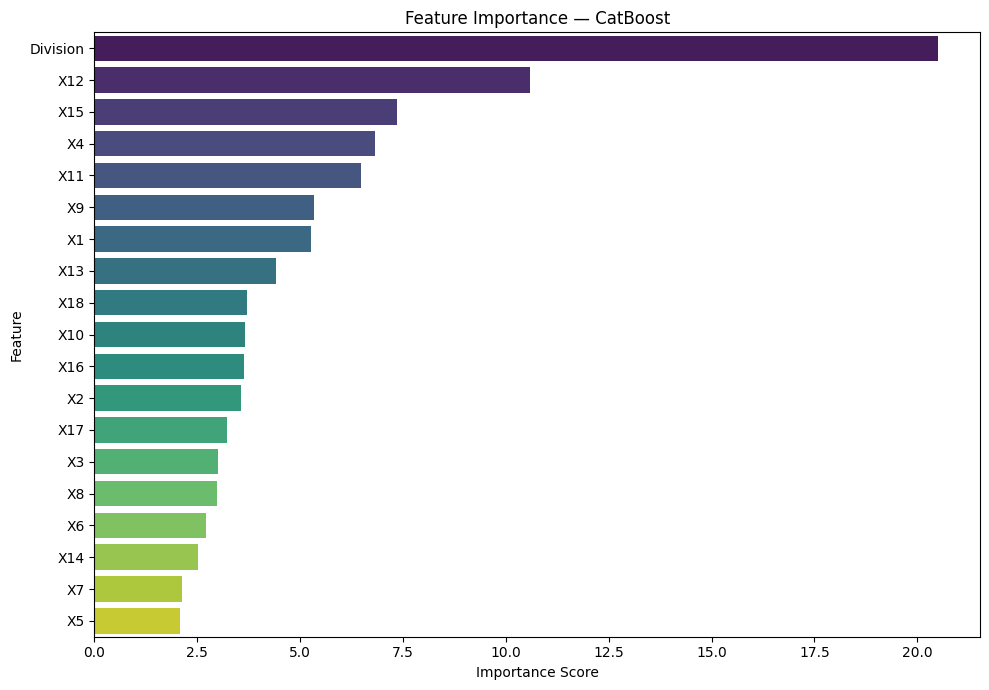

     Feature  Importance
18  Division   20.498916
11       X12   10.595210
14       X15    7.367557
3         X4    6.832367
10       X11    6.471406
8         X9    5.351329
0         X1    5.274726
12       X13    4.404991
17       X18    3.701700
9        X10    3.657689
15       X16    3.633871
1         X2    3.564839
16       X17    3.221205
2         X3    2.997555
7         X8    2.975742
5         X6    2.710283
13       X14    2.529492
6         X7    2.123852
4         X5    2.087269


In [15]:
feature_importance = pd.DataFrame({
    'Feature': FEATURES,
    'Importance': model.get_feature_importance()
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(10,7))
sns.barplot(x='Importance', y='Feature', 
            data=feature_importance,
            palette='viridis')
plt.title('Feature Importance — CatBoost')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

print(feature_importance)

In [16]:
print("=== Threshold Tuning ===\n")
for t in [0.3, 0.4, 0.5, 0.6, 0.7]:
    preds = (y_test_proba >= t).astype(int)
    print(f"--- Threshold: {t} ---")
    print(classification_report(y_test, preds, target_names=['Alive', 'Failed']))

=== Threshold Tuning ===

--- Threshold: 0.3 ---
              precision    recall  f1-score   support

       Alive       0.99      0.58      0.73     11995
      Failed       0.05      0.85      0.09       287

    accuracy                           0.59     12282
   macro avg       0.52      0.72      0.41     12282
weighted avg       0.97      0.59      0.72     12282

--- Threshold: 0.4 ---
              precision    recall  f1-score   support

       Alive       0.99      0.77      0.87     11995
      Failed       0.07      0.70      0.13       287

    accuracy                           0.77     12282
   macro avg       0.53      0.74      0.50     12282
weighted avg       0.97      0.77      0.85     12282

--- Threshold: 0.5 ---
              precision    recall  f1-score   support

       Alive       0.99      0.91      0.95     11995
      Failed       0.12      0.51      0.19       287

    accuracy                           0.90     12282
   macro avg       0.55      0.71

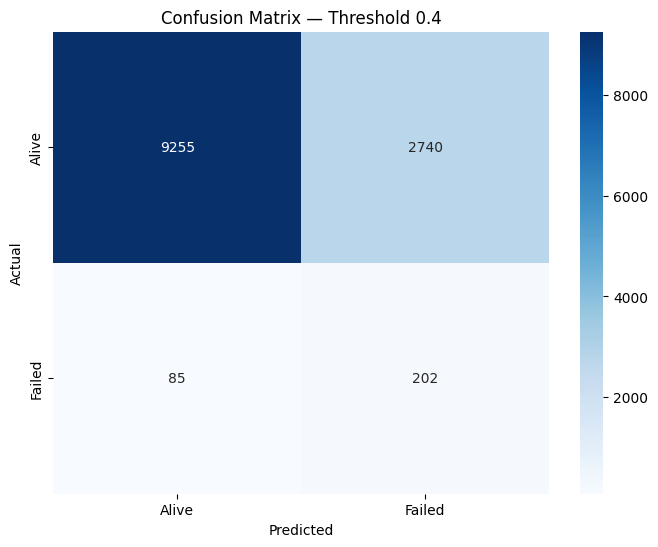

In [17]:
final_preds = (y_test_proba >= 0.4).astype(int)
cm = confusion_matrix(y_test, final_preds)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Alive', 'Failed'],
            yticklabels=['Alive', 'Failed'])
plt.title('Confusion Matrix — Threshold 0.4')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()